# 03.1 - BiLSTM **+ CRF** (structured decoding)
**NLP Deliverable 2 — improving the from-scratch DL model #1**

The plain BiLSTM (notebook `03`) predicts each word's tag **independently**, so nothing
stops it from producing **invalid BIO sequences** (e.g. `O I-per`, or `B-geo I-org`). It
also over-fits heavily when trained for many epochs (train F1 ≈ 0.99 vs test F1 ≈ 0.52).

This notebook adds two improvements **without leaving the RNN world**:

1. **A CRF layer on top of the BiLSTM** — instead of an independent softmax per word, a
   *linear-chain CRF* scores the **whole tag sequence** and learns **transition scores**
   between tags. At inference it runs **Viterbi** to return the single best *globally
   consistent* sequence. This removes impossible transitions and typically boosts F1.
2. **Regularization** — a validation split with **early stopping** + weight decay, so we
   stop before the model memorizes the training set.

Saved artifacts: `fitted_models/bilstm_crf_model.pth` + `fitted_models/bilstm_crf_mappings.pkl`.

> Colab-friendly: installs `pytorch-crf`, auto-detects cuda/mps/cpu, and falls back to a
> small subset / few epochs on CPU so it still runs end-to-end.

In [1]:
# === Setup ===
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q pytorch-crf
    DATA_DIR = '.'
else:
    DATA_DIR = '../nlp_d2_data'
FITTED_DIR = 'fitted_models'; os.makedirs(FITTED_DIR, exist_ok=True)

import warnings; warnings.filterwarnings('ignore')
import pickle, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchcrf import CRF
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
FULL = device.type == 'cuda'
print('Device:', device, '| FULL training:', FULL)

Device: cuda | FULL training: True


## 1. Load data

In [2]:
def load_data(path):
    df = pd.read_csv(path)
    df['words'] = df['words'].astype(str); df['sentence_id'] = df['sentence_id'].astype(int)
    return [list(zip(g['words'].tolist(), g['tags'].tolist()))
            for _, g in df.groupby('sentence_id', sort=True)]

train_all  = load_data(os.path.join(DATA_DIR, 'train_data_ner.csv'))
test_sents = load_data(os.path.join(DATA_DIR, 'test_data_ner.csv'))
if not FULL:
    train_all = train_all[:4000]

# validation split (for early stopping) — 10% of train
random.shuffle(train_all)
n_val = max(1, int(0.1*len(train_all)))
val_sents, train_sents = train_all[:n_val], train_all[n_val:]
print(f'train: {len(train_sents)} | val: {len(val_sents)} | test: {len(test_sents)}')

train: 34530 | val: 3836 | test: 38367


## 2. Vocab and tag mappings

For the CRF we use **real tags only** (no `<PAD>` tag): padded positions are handled by a
**mask**, not by a fake tag. Tags are indexed from `0`.

In [3]:
word_to_ix = {'<PAD>': 0, '<UNK>': 1}
tag_to_ix  = {}                                  # real tags only, indexed from 0
for sent in train_sents:
    for w, t in sent:
        if w not in word_to_ix: word_to_ix[w] = len(word_to_ix)
        if t not in tag_to_ix:  tag_to_ix[t]  = len(tag_to_ix)
ix_to_tag = {v: k for k, v in tag_to_ix.items()}
NUM_TAGS = len(tag_to_ix)

HP = dict(embedding_dim=300, hidden_dim=128, max_len=60, batch_size=64,
          epochs=(45 if FULL else 12), lr=1e-3, dropout=0.5,
          weight_decay=1e-4, patience=6)

with open(os.path.join(FITTED_DIR, 'bilstm_crf_mappings.pkl'), 'wb') as fh:
    pickle.dump({'word_to_ix': word_to_ix, 'tag_to_ix': tag_to_ix,
                 'ix_to_tag': ix_to_tag, 'hp': HP}, fh)
print(f'vocab: {len(word_to_ix)} | tags: {NUM_TAGS}')

vocab: 30516 | tags: 17


## 3. Dataset and model

`NERDataset` pads to `max_len` and uses **word index 0 (`<PAD>`)** for padding. The mask is
simply `X != 0`; padded tag positions are set to `0` but are *masked out* of the CRF.

In [4]:
class NERDataset(Dataset):
    def __init__(self, sents, w2i, t2i, max_len):
        self.sents, self.w2i, self.t2i, self.max_len = sents, w2i, t2i, max_len
    def __len__(self): return len(self.sents)
    def __getitem__(self, idx):
        sent = self.sents[idx]
        X = [self.w2i.get(w, 1) for w, _ in sent][:self.max_len]
        y = [self.t2i[t] for _, t in sent][:self.max_len]
        pad = self.max_len - len(X)
        X = X + [0]*pad; y = y + [0]*pad
        return torch.tensor(X), torch.tensor(y)

class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, num_tags, embedding_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, num_tags)       # -> emission scores
        self.crf = CRF(num_tags, batch_first=True)        # -> transition scores + Viterbi
    def emissions(self, x):
        e = self.dropout(self.embedding(x))
        h, _ = self.lstm(e)
        return self.fc(self.dropout(h))
    def loss(self, x, tags, mask):
        em = self.emissions(x)
        return -self.crf(em, tags, mask=mask, reduction='mean')   # neg log-likelihood
    def decode(self, x, mask):
        return self.crf.decode(self.emissions(x), mask=mask)      # Viterbi best path

## 4. Training with early stopping

The CRF loss is the **negative log-likelihood** of the gold tag sequence; minimizing it
pushes up the score of correct sequences relative to *all* possible sequences (the
partition function). We monitor validation F1 and keep the best checkpoint.

In [ ]:
def make_loader(sents, shuffle):
    return DataLoader(NERDataset(sents, word_to_ix, tag_to_ix, HP['max_len']),
                      batch_size=HP['batch_size'], shuffle=shuffle)
train_loader, val_loader = make_loader(train_sents, True), make_loader(val_sents, False)

model = BiLSTM_CRF(len(word_to_ix), NUM_TAGS, HP['embedding_dim'],
                   HP['hidden_dim'], HP['dropout']).to(device)
optimizer = optim.Adam(model.parameters(), lr=HP['lr'], weight_decay=HP['weight_decay'])

@torch.no_grad()
def eval_loss(loader):
    model.eval(); tot = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        mask = (xb != 0); mask[:, 0] = True
        tot += model.loss(xb, yb, mask).item()
    return tot/len(loader)

best_val, best_state, bad = float('inf'), None, 0
for epoch in range(HP['epochs']):
    model.train(); tot = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        mask = (xb != 0); mask[:, 0] = True
        optimizer.zero_grad()
        loss = model.loss(xb, yb, mask)
        loss.backward(); optimizer.step(); tot += loss.item()
    vloss = eval_loss(val_loader)
    print(f'Epoch {epoch+1}/{HP["epochs"]} - train {tot/len(train_loader):.4f} | val {vloss:.4f}')
    if vloss < best_val - 1e-4:
        best_val, best_state, bad = vloss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
    else:
        bad += 1
        if bad >= HP['patience']:
            print(f'Early stopping at epoch {epoch+1}'); break

model.load_state_dict(best_state)
torch.save(model.state_dict(), os.path.join(FITTED_DIR, 'bilstm_crf_model.pth'))
print('Saved fitted_models/bilstm_crf_model.pth (best val loss = %.4f)' % best_val)

Epoch 1/45 - train 11.2807 | val 5.0639
Epoch 2/45 - train 5.1196 | val 3.2112
Epoch 3/45 - train 3.6120 | val 2.4520
Epoch 4/45 - train 2.7913 | val 2.1560
Epoch 5/45 - train 2.3063 | val 1.9027
Epoch 6/45 - train 1.9716 | val 1.7180
Epoch 7/45 - train 1.7497 | val 1.6260
Epoch 8/45 - train 1.5691 | val 1.6209
Epoch 9/45 - train 1.4502 | val 1.5380
Epoch 10/45 - train 1.3503 | val 1.5232
Epoch 11/45 - train 1.2643 | val 1.4802
Epoch 12/45 - train 1.1950 | val 1.4813
Epoch 13/45 - train 1.1371 | val 1.4998
Epoch 14/45 - train 1.0895 | val 1.4471
Epoch 15/45 - train 1.0417 | val 1.4867
Epoch 16/45 - train 1.0007 | val 1.4450
Epoch 17/45 - train 0.9638 | val 1.4744
Epoch 18/45 - train 0.9217 | val 1.4975
Epoch 19/45 - train 0.8962 | val 1.5109
Epoch 20/45 - train 0.8544 | val 1.5215
Epoch 21/45 - train 0.8222 | val 1.5844
Epoch 22/45 - train 0.8003 | val 1.6527
Early stopping at epoch 22
Saved fitted_models/bilstm_crf_model.pth (best val loss = 1.4450)


## 5. Evaluation

In [ ]:
@torch.no_grad()
def predict(model, sents, batch_size=128):
    model.eval(); preds = []
    for start in range(0, len(sents), batch_size):
        chunk = sents[start:start+batch_size]
        lens = [len(s) for s in chunk]
        m = max(lens)
        X = torch.zeros(len(chunk), m, dtype=torch.long)
        for b, s in enumerate(chunk):
            ids = [word_to_ix.get(w, 1) for w, _ in s]
            X[b, :len(ids)] = torch.tensor(ids)
        X = X.to(device)
        mask = (X != 0); mask[:, 0] = True
        paths = model.decode(X, mask)                 # list of best tag-id paths
        for b, p in enumerate(paths):
            preds.append([ix_to_tag[i] for i in p[:lens[b]]])
    return preds

def flatten(s): return [x for sub in s for x in sub]
def non_o_accuracy(yt, yp):
    yt, yp = flatten(yt), flatten(yp)
    idx = [k for k,t in enumerate(yt) if t!='O']
    return accuracy_score([yt[k] for k in idx], [yp[k] for k in idx])
def weighted_f1(yt, yp):
    yt, yp = flatten(yt), flatten(yp); labels = sorted(set(yt)-{'O'})
    return f1_score(yt, yp, average='weighted', labels=labels, zero_division=0)

y_train = [[t for _,t in s] for s in train_sents]
y_test  = [[t for _,t in s] for s in test_sents]
yp_train, yp_test = predict(model, train_sents), predict(model, test_sents)
print(f"Train non-O accuracy: {non_o_accuracy(y_train, yp_train):.4f} | F1: {weighted_f1(y_train, yp_train):.4f}")
print(f"Test  non-O accuracy: {non_o_accuracy(y_test,  yp_test):.4f} | F1: {weighted_f1(y_test,  yp_test):.4f}")

Train non-O accuracy: 0.9328 | F1: 0.9306
Test  non-O accuracy: 0.3565 | F1: 0.4717


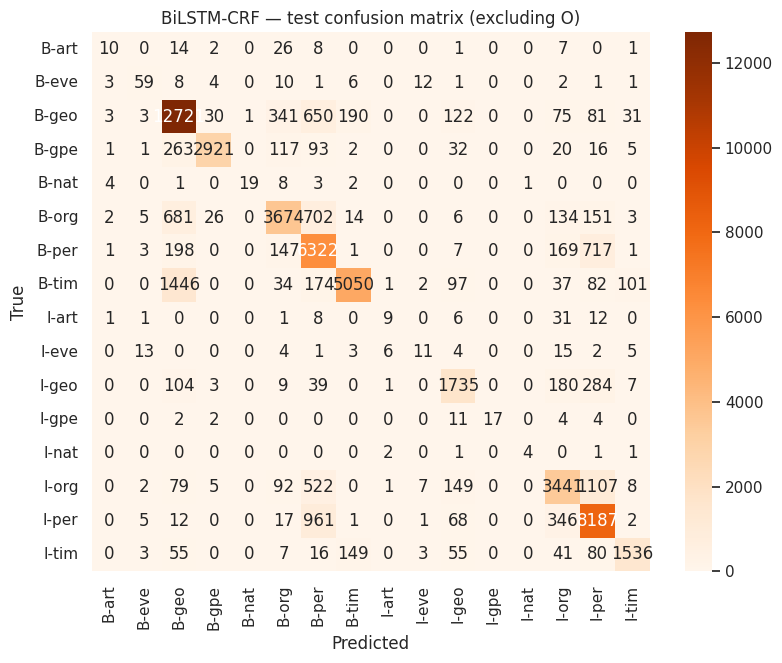

In [ ]:
yt, yp = flatten(y_test), flatten(yp_test)
labels = sorted(set(yt)-{'O'})
cm = confusion_matrix(yt, yp, labels=labels)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.title('BiLSTM-CRF — test confusion matrix (excluding O)')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.show()

## 6. TINY TEST

In [ ]:
tiny_sents = load_data(os.path.join(DATA_DIR, 'tiny_test.csv'))
y_tiny = [[t for _,t in s] for s in tiny_sents]
yp_tiny = predict(model, tiny_sents)
print('=== TINY TEST — BiLSTM-CRF ===')
for s, pred in zip(tiny_sents, yp_tiny):
    print(' '.join(f'{w}/{t}' for (w,_),t in zip(s, pred)))
print(f'\nTiny-test accuracy (non-O): {non_o_accuracy(y_tiny, yp_tiny):.4f}')

=== TINY TEST — BiLSTM-CRF ===
The/O programmers/O from/O Barcelona/B-geo might/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
The/O programmers/O from/O Barchelona/O cannot/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
Jack/B-per London/B-geo went/O to/O Parris/O ./O
Jack/B-per London/B-geo went/O to/O Paris/B-geo ./O
Bill/B-per gates/I-per and/O Steve/B-per jobs/O never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
Bill/B-per Gates/I-per and/O Steve/B-per Jobs/I-per never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
The/O president/O of/O U.S.A/B-geo thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-geo States/I-geo of/I-geo America/I-geo thought/O they/O could/O win/O the/O war/O ./O
The/O king/O of/O Saudi/B-geo Arabia/I-geo wanted/O total/O control/O ./O
Robin/O does/O not/O want/O to/O go/O to/O Saudi/B-geo Arabia/I-geo ./O
Apple/B-org is/O a/O great/O comp

## 7. Why the CRF helps

A linear-chain CRF models the score of a full tag sequence **y** for input **x** as:

`score(x, y) = Σ_t  Emission_t(y_t)  +  Σ_t  Transition(y_{t-1} → y_t)`

- **Emission** scores come from the BiLSTM (one per word/tag).
- **Transition** scores are a learned `T × T` matrix shared across positions: it penalizes
  illegal jumps (e.g. `O → I-per`) and rewards valid ones (`B-per → I-per`).

Training maximizes the log-probability of the gold sequence (softmax over *all* sequences,
computed efficiently with the forward algorithm). Decoding uses **Viterbi** to pick the
single highest-scoring path, so the output is always globally consistent.

**Limitation that remains:** OOV. Test words unseen in train still map to `<UNK>`. That is
exactly what notebook `03.2` (GloVe) addresses. Combining **GloVe embeddings + a CRF head**
is usually the strongest non-transformer recipe.